In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("viagens.csv")

# remover duplicados
df = df.drop_duplicates()

# preencher valores ausentes
df["atraso_min"] = df["atraso_min"].fillna(df["atraso_min"].mean())

# anonimização
df["trem_id"] = df["trem_id"].astype("category").cat.codes
#Padronização textual
df["clima"] = df["clima"].str.upper()
#Estatística Descritiva
#Média de atraso
df["atraso_min"].mean()




In [ ]:
#Frequência de categorias
df["status_viagem"].value_counts()

,count
status_viagem,
CONCLUIDA,3
ATRASADA,1
ADIANTADA,1


In [ ]:
#Clusterização Hierárquica
#Variáveis utilizadas
#atraso_min
#carga_ton
#velocidade_media_kmh



Modelo utilizadoModelo utilizado

In [ ]:
from sklearn.cluster import AgglomerativeClustering

X = df[[
    "atraso_min",
    "velocidade_media_kmh",
    "carga_ton"
]]

modelo = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

df["cluster"] = modelo.fit_predict(X)

In [ ]:
df["cluster"]

,cluster
0,0
1,0
2,1
3,1
4,2


5. Visualização de Dados Categóricos<br>
5.1 Status das Viagens<br>
Distribuição do status das viagens

<Axes: ylabel='count'>

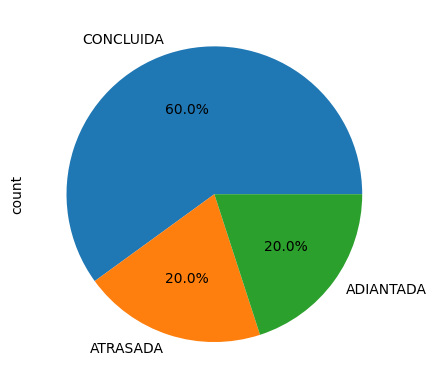

In [ ]:
df["status_viagem"].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

5.2 Média de atraso por linha
Atraso médio por linha ferroviária

<Axes: xlabel='linha'>

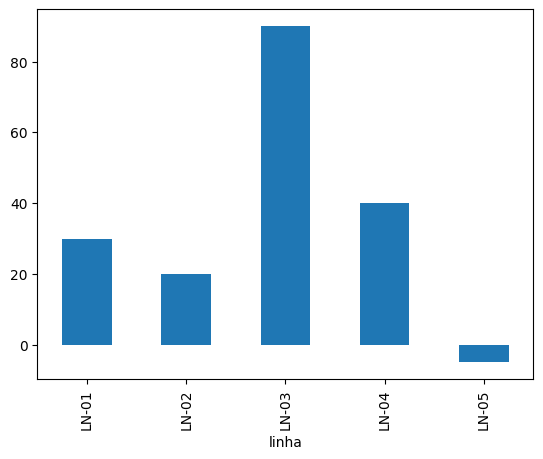

In [ ]:
media = df.groupby("linha")[
    "atraso_min"
].mean()

media.plot(kind='bar')

3. Comparação entre categorias<br>


Atraso médio por linha:<br>

Comparação do atraso médio entre linhas ferroviárias.<br>

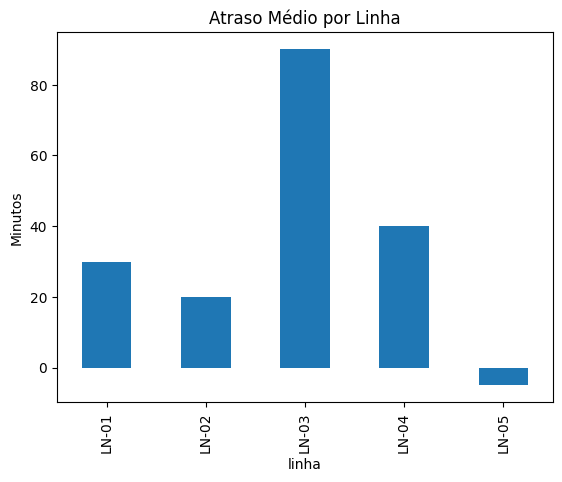

In [ ]:
media = df.groupby("linha")["atraso_min"].mean()

media.plot(kind='bar')

plt.title("Atraso Médio por Linha")
plt.ylabel("Minutos")

plt.show()

In [ ]:
import io
import pandas as pd

# Data for manutencao.csv from markdown cell sLxfluKonQ0n
manutencao_data = """id_manutencao,trem_id,data,tipo_manutencao,custo_brl,tempo_parado_h,falha_detectada,peca_substituida
5001,TR-100,2025-12-20,Preventiva,12000,6,NÃO,Filtro de óleo
5002,TR-101,2025-12-22,Corretiva,45000,18,SIM,Sistema de freios
5003,TR-102,2025-12-23,Preventiva,15000,8,NÃO,Rolamentos
5004,TR-103,2025-12-24,Corretiva,67000,24,SIM,Motor elétrico"""

df_manutencao = pd.read_csv(io.StringIO(manutencao_data))

# Trens com mais falhas (translated from SQL)
trens_com_falhas = df_manutencao[df_manutencao['falha_detectada'] == 'SIM'] \
                         .groupby('trem_id').size().reset_index(name='qtd_falhas')

sorted_trens_com_falhas = trens_com_falhas.sort_values(by='qtd_falhas', ascending=False)

print(sorted_trens_com_falhas)

In [ ]:
# Assuming 'trem_id' refers to 'linha' as a unique identifier for analysis related to trains/routes,
# and 'falha_detectada = 'SIM'' maps to 'status_manutencao == 'FALHA''
failures_per_line = df[df['status_manutencao'] == 'FALHA'].groupby('linha').size().reset_index(name='qtd_falhas')

# Sort by count in descending order
sorted_failures = failures_per_line.sort_values(by='qtd_falhas', ascending=False)

print(sorted_failures)

Trens com mais falhas

In [ ]:
# Assuming 'trem_id' refers to 'linha' as a unique identifier for analysis related to trains/routes,
# and 'falha_detectada = 'SIM'' maps to 'status_manutencao == 'FALHA''
failures_per_line = df[df['status_manutencao'] == 'FALHA'].groupby('linha').size().reset_index(name='qtd_falhas')

# Sort by count in descending order
sorted_failures = failures_per_line.sort_values(by='qtd_falhas', ascending=False)

print(sorted_failures)

   linha  qtd_falhas
3  LN-04           2
0  LN-01           1
1  LN-02           1
2  LN-03           1


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

df = pd.read_csv("viagens.csv")

X = df[["distancia_km", "carga_ton", "passageiros"]]
y = df["atraso_min"]

X_train, X_test, y_train, y_test = train_test_split(X, y)

model = RandomForestRegressor()
model.fit(X_train, y_train)

print("Score:", model.score(X_test, y_test))

-9.374208


In [ ]:
# Média de atraso por linha
print(df.groupby('linha')['atraso_min'].mean())

linha
LN-01    30.0
LN-02    20.0
LN-03    90.0
LN-04    40.0
LN-05    -5.0
Name: atraso_min, dtype: float64


In [ ]:

import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

df = pd.read_csv("viagens.csv")

X = df[["distancia_km", "carga_ton", "passageiros"]]
y = df["atraso_min"]

X_train, X_test, y_train, y_test = train_test_split(X, y)

model = RandomForestRegressor()
model.fit(X_train, y_train)

print(model.score(X_test, y_test))

-24.061049999999994


In [ ]:
import io
import pandas as pd

# Data for manutencao.csv from markdown cell sLxfluKonQ0n
manutencao_data = """id_manutencao,trem_id,data,tipo_manutencao,custo_brl,tempo_parado_h,falha_detectada,peca_substituida
5001,TR-100,2025-12-20,Preventiva,12000,6,NÃO,Filtro de óleo
5002,TR-101,2025-12-22,Corretiva,45000,18,SIM,Sistema de freios
5003,TR-102,2025-12-23,Preventiva,15000,8,NÃO,Rolamentos
5004,TR-103,2025-12-24,Corretiva,67000,24,SIM,Motor elétrico"""

df_manutencao = pd.read_csv(io.StringIO(manutencao_data))

# Trens com mais falhas (translated from SQL)
trens_com_falhas = df_manutencao[df_manutencao['falha_detectada'] == 'SIM'] \
                         .groupby('trem_id').size().reset_index(name='qtd_falhas')

sorted_trens_com_falhas = trens_com_falhas.sort_values(by='qtd_falhas', ascending=False)

print(sorted_trens_com_falhas)

  trem_id  qtd_falhas
0  TR-101           1
1  TR-103           1
